In [ ]:
import pathlib
import random
from typing import Dict, List, Sequence, Tuple, Union

In [ ]:
try:
    import cupy as cp
except ImportError:
    import numpy as cp

import marimo as mo
import numpy as np
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp
from tqdm.auto import tqdm
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-04-28T04:06:28.829744+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

marimo : 0.23.2
pandas : 2.2.3
seaborn: 0.13.2
numpy  : 2.1.2
teeplot: 1.4.2

```

In [ ]:
use_cupy = False  # use cupy backend (GPU), otherwise use numpy (CPU)
xp = [np, cp][use_cupy]

## Simulation Implementation

In [ ]:
def simulate(
    N_SITES: int = 2,
    POP_SIZE: int = 1_000_000,
    CONTACT_RATE: float = 0.3,
    RECOVERY_RATE: float = 0.1,
    MUTATION_RATE: Union[float, Sequence[float]] = 1e-4,
    WANING_RATE: float = 0.02,
    IMMUNE_STRENGTH: float = 0.9,
    N_STEPS: int = 1_000,
    SEED_COUNT: int = 10,
    within_host_b: float = 0.2,
    within_host_t: float = 25.0,
    seed: int = 1,
    MUTATOR_HOSTS_N: int = 0,
    MUTATOR_HOSTS_MX: float = 1.0,
    MUTATION_THRESHOLD: float = 0.0,
    IMMUNITY_CEILING: float = 1.0,
    IMMUNITY_FLOOR: float = 0.0,
    track_phylogeny: bool = False,
) -> Union[pd.DataFrame, Tuple[pd.DataFrame, pd.DataFrame]]:
    random.seed(seed)
    np.random.seed(seed)
    xp.random.seed(seed)

    MUTATION_RATE = xp.asarray(MUTATION_RATE, dtype=xp.float32)

    if N_SITES > 16:
        raise NotImplementedError(
            "current data types support only up to 16 sites",
        )

    # Phylogeny tracking state. Each entry corresponds to one infection
    # event (initial seed or onward transmission); ancestor_id of a root
    # references itself, per the alife data standard.
    phylo_ids: List[int] = []
    phylo_ancestor_ids: List[int] = []
    phylo_origin_times: List[int] = []
    phylo_genomes: List[int] = []
    next_node_id = [0]

    def initialize_pop() -> (
        Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]
    ):
        """Initialize population statuses, genomes, and immune history."""
        # uint16 to support up to 16 sites (uint8 caps at 8).
        pathogen_genomes = xp.zeros(shape=POP_SIZE, dtype=xp.uint16)
        # host_immunities: Tracks each of the 2*N_SITES alleles
        host_immunities = xp.full(
            shape=(POP_SIZE, 2 * N_SITES),
            fill_value=0.0,
            dtype=xp.float32,
        )
        # host_statuses: days since infection (0 if not infected)
        host_statuses = xp.full(
            shape=POP_SIZE, fill_value=0, dtype=xp.uint8
        )
        # pathogen_node_ids: phylogeny node id of each host's pathogen
        # (only populated when track_phylogeny=True; -1 means uninfected)
        pathogen_node_ids = xp.full(
            shape=POP_SIZE, fill_value=-1, dtype=xp.int64
        )

        return (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_node_ids,
        )

    def infect_initial(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        pathogen_node_ids: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray]:
        """Seed the initial infection wave with the starting strain."""
        seeded_indices = xp.random.choice(
            POP_SIZE, size=SEED_COUNT, replace=False
        )
        host_statuses[seeded_indices] = 1
        pathogen_genomes[seeded_indices] = 0  # wildtype
        if track_phylogeny:
            for idx in seeded_indices.tolist():
                nid = next_node_id[0]
                phylo_ids.append(nid)
                phylo_ancestor_ids.append(nid)  # root self-reference
                phylo_origin_times.append(0)
                phylo_genomes.append(0)
                pathogen_node_ids[idx] = nid
                next_node_id[0] += 1
        return host_statuses, pathogen_genomes, pathogen_node_ids

    def calc_infection_probabilities(
        host_immunities: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> xp.ndarray:
        host_susceptibilities = xp.reshape(
            1.0 - (IMMUNE_STRENGTH * host_immunities),
            (POP_SIZE, 2 * N_SITES),
        )

        pathogen_bits = (
            pathogen_genomes[:, None] >> xp.arange(N_SITES)
        ) & 1
        pathogen_alleles = (
            pathogen_bits[:, :, None] == xp.array([0, 1])
        ).reshape(-1, 2 * N_SITES)

        active_susc = xp.where(
            pathogen_alleles, host_susceptibilities, 1.0
        )
        res = xp.prod(active_susc, axis=1)
        assert res.shape == (POP_SIZE,)
        return res

    if MUTATION_RATE.size == 1:

        def calc_mutation_probabilities(
            host_immunities: xp.ndarray,
            pathogen_genomes: xp.ndarray,
        ) -> xp.ndarray:
            pathogen_bits = (
                pathogen_genomes[:, None] >> xp.arange(N_SITES)
            ) & 1

            imm_reshaped = xp.reshape(host_immunities, (-1, N_SITES, 2))

            idx_curr = pathogen_bits[:, :, None]
            idx_opp = 1 - idx_curr

            imm_curr = xp.take_along_axis(
                imm_reshaped, idx_curr, axis=2
            ).squeeze(axis=2)
            imm_opp = xp.take_along_axis(
                imm_reshaped, idx_opp, axis=2
            ).squeeze(axis=2)

            host_immunity_deltas = imm_curr - imm_opp

            b_values = 1.0 + within_host_b * host_immunity_deltas
            b_values = xp.where(
                xp.abs(b_values - 1.0) < 1e-7, 1.000001, b_values
            )

            # \\frac{y}{x} = \\frac{m}{b-1} \\left( e^{(b-1)t} - 1 \\right)
            return (MUTATION_RATE / (b_values - 1.0)) * (
                xp.exp((b_values - 1.0) * within_host_t) - 1.0
            )

    else:

        def calc_mutation_probabilities(
            host_immunities: xp.ndarray,
            pathogen_genomes: xp.ndarray,
        ) -> xp.ndarray:
            n_infected = host_immunities.shape[0]
            return (
                xp.ones((n_infected, 1), dtype=MUTATION_RATE.dtype)
                * MUTATION_RATE
            )

    def update_waning(host_immunities: xp.ndarray) -> xp.ndarray:
        """Decay immunity levels over time."""
        host_immunities *= 1.0 - WANING_RATE
        host_immunities[host_immunities > 0] = xp.clip(
            host_immunities[host_immunities > 0],
            IMMUNITY_FLOOR,
            IMMUNITY_CEILING,
        )
        return host_immunities

    def update_recoveries(
        host_statuses: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray]:
        """Recover infected individuals with probability RECOVERY_RATE."""
        # Each infected host recovers independently at rate RECOVERY_RATE,
        # regardless of how long they have been infected. This matches the
        # ODE's per-person recovery rate.
        recovered_mask = (host_statuses >= 1) * xp.random.rand(
            POP_SIZE
        ) > 1 - RECOVERY_RATE

        pathogen_bits = (
            pathogen_genomes[:, None] >> xp.arange(N_SITES)
        ) & 1
        pathogen_alleles = (
            pathogen_bits[:, :, None] == xp.array([0, 1])
        ).reshape(-1, 2 * N_SITES)

        assert np.all(
            pathogen_alleles[recovered_mask].sum(axis=1) == N_SITES
        )

        host_immunities[
            pathogen_alleles.astype(bool) & recovered_mask[:, None]
        ] = 1.0

        host_statuses += (host_statuses > 0).astype(xp.uint8)
        host_statuses[recovered_mask] = 0

        return host_statuses, host_immunities

    def transmit_infection(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_node_ids: xp.ndarray,
        step: int,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray]:
        """Vectorized transmission based on allele-specific susceptibility."""
        contacts = xp.random.randint(
            low=0, high=POP_SIZE, size=POP_SIZE, dtype=xp.uint32
        )
        inf_probs = (
            calc_infection_probabilities(
                host_immunities, pathogen_genomes[contacts]
            )
            * (host_statuses == 0)
            * (host_statuses[contacts] > 0)
            * CONTACT_RATE
        )

        new_infections = xp.random.rand(POP_SIZE) < inf_probs
        host_statuses[new_infections] = 1
        pathogen_genomes[new_infections] = pathogen_genomes[contacts][
            new_infections
        ]

        if track_phylogeny:
            # Bulk-extend Python lists (per-event appends are ~10x slower
            # at million-event scale).
            new_idx = xp.where(new_infections)[0]
            n_new = int(new_idx.size)
            if n_new:
                src_node_ids = pathogen_node_ids[contacts[new_infections]]
                new_ids = xp.arange(
                    next_node_id[0],
                    next_node_id[0] + n_new,
                    dtype=xp.int64,
                )
                phylo_ids.extend(new_ids.tolist())
                phylo_ancestor_ids.extend(src_node_ids.tolist())
                phylo_origin_times.extend([int(step)] * n_new)
                phylo_genomes.extend(
                    pathogen_genomes[new_infections].tolist(),
                )
                pathogen_node_ids[new_idx] = new_ids
                next_node_id[0] += n_new

        return host_statuses, pathogen_genomes, pathogen_node_ids

    def apply_mutations(
        pathogen_genomes: xp.ndarray,
        host_statuses: xp.ndarray,
    ) -> xp.ndarray:
        """Apply mutations to newly infected individuals."""
        mutation_mask = (host_statuses == 1).astype(bool)

        mprobs = calc_mutation_probabilities(
            host_immunities[mutation_mask],
            pathogen_genomes[mutation_mask],
        )
        mutator_n = host_statuses[:MUTATOR_HOSTS_N].sum()
        mprobs[:mutator_n] = xp.minimum(
            mprobs[:mutator_n] * MUTATOR_HOSTS_MX, 1.0
        )

        mprobs[mprobs < MUTATION_THRESHOLD] = 0.0

        for s in range(N_SITES):
            mutation_occurs = (
                xp.random.rand(mprobs.shape[0]) < mprobs[:, s]
            ).astype(xp.uint16)
            pathogen_genomes[mutation_mask] ^= (
                mutation_occurs << s
            ).astype(xp.uint16)

        return pathogen_genomes

    def update_simulation(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_node_ids: xp.ndarray,
        step: int,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]:
        """Run one step of the simulation."""
        (
            host_statuses,
            pathogen_genomes,
            pathogen_node_ids,
        ) = transmit_infection(
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_node_ids,
            step,
        )
        pathogen_genomes = apply_mutations(pathogen_genomes, host_statuses)
        host_statuses, host_immunities = update_recoveries(
            host_statuses, host_immunities, pathogen_genomes
        )
        host_immunities = update_waning(host_immunities)

        return (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_node_ids,
        )

    (
        host_statuses,
        pathogen_genomes,
        host_immunities,
        pathogen_node_ids,
    ) = initialize_pop()
    host_statuses, pathogen_genomes, pathogen_node_ids = infect_initial(
        host_statuses, pathogen_genomes, pathogen_node_ids
    )
    data_log: List[Dict[str, float]] = []

    for t in tqdm(range(N_STEPS)):
        (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_node_ids,
        ) = update_simulation(
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_node_ids,
            t + 1,
        )

        inf_mask = host_statuses > 0
        counts_dict: Dict[str, float] = {}

        if xp.any(inf_mask):
            unique_g, counts = xp.unique(
                pathogen_genomes[inf_mask], return_counts=True
            )

            for g, count in zip(unique_g.tolist(), counts.tolist()):
                fmt = f"0{N_SITES}b"
                strain_name = format(int(g), fmt)[::-1]
                counts_dict[f"Strain_{strain_name}"] = (
                    float(count) / POP_SIZE
                )

        avg_susc = xp.mean(
            1.0 - (IMMUNE_STRENGTH * host_immunities), axis=0
        )

        immunity_dict = {}
        for i in range(2 * N_SITES):
            site = i // 2
            bit = i % 2
            immunity_dict[f"Susc_S{site}_B{bit}"] = float(avg_susc[i])

        log_entry = {
            "Step": t,
            "Seed": seed,
            "Total_Infected": float(xp.sum(inf_mask)) / POP_SIZE,
        }
        log_entry.update(counts_dict)
        log_entry.update(immunity_dict)
        data_log.append(log_entry)

    df = pd.DataFrame(data_log).fillna(0).copy()
    if not track_phylogeny:
        return df

    # Mark nodes whose lineage is still extant at end of simulation,
    # i.e. at least one currently-infected host carries that node's id.
    extant_node_ids = set(
        int(nid) for nid in pathogen_node_ids[host_statuses > 0].tolist()
    )
    phylogeny_df = pd.DataFrame(
        {
            "id": phylo_ids,
            "ancestor_id": phylo_ancestor_ids,
            "origin_time": phylo_origin_times,
            "genome": phylo_genomes,
            "extant": [nid in extant_node_ids for nid in phylo_ids],
        }
    )
    return df, phylogeny_df

## Exact Phylogeny Tracking

Run an example with `track_phylogeny=True` to record an alife-standard
phylogeny (`id` / `ancestor_id` / `origin_time`) of pathogen lineages,
including extinct lineages, then visualize with `iplotx`.

In [ ]:
# Baseline ABM/ODE-sync params from the sync notebook, scaled up for an
# exact-phylogeny demo at 200k pop x 600 steps.
PHYLO_POP_SIZE = 200_000
PHYLO_N_STEPS = 1_200
PHYLO_N_SITES = 10
PHYLO_MUTATION_RATE = 5e-5

phylo_df, phylogeny_df = simulate(
    MUTATION_RATE=PHYLO_MUTATION_RATE,
    N_SITES=PHYLO_N_SITES,
    N_STEPS=PHYLO_N_STEPS,
    POP_SIZE=PHYLO_POP_SIZE,
    CONTACT_RATE=0.35,
    RECOVERY_RATE=0.1,
    WANING_RATE=0.005,
    IMMUNE_STRENGTH=0.7,
    SEED_COUNT=2,
    IMMUNITY_FLOOR=0.05,
    IMMUNITY_CEILING=1.0,
    seed=2,
    track_phylogeny=True,
)

100%|██████████| 1200/1200 [02:33<00:00,  7.79it/s]


In [ ]:
print(f"phylogeny: {len(phylogeny_df)} total nodes")
print(f"phylogeny: {phylogeny_df['extant'].sum()} extant tips")
phylogeny_df.head()

phylogeny: 191325 total nodes
phylogeny: 0 extant tips


,id,ancestor_id,origin_time,genome,extant
0,0,0,0,0,False
1,1,1,0,0,False
2,2,0,1,0,False
3,3,1,1,0,False
4,4,3,2,0,False


### Plot Phylogeny with iplotx

Render the full phylogeny (including extinct lineages) via `iplotx`,
uniformly downsampled to ≤500 tips with `phyloframe`. Tips are colored by
founder strain; the adjacent stackplot shows population composition over
time with strains stacked in order of increasing Hamming weight so
bit-weight composition reads bottom-to-top.

phylogeny: 191325 total nodes
downsampled tree: 16634 nodes
leaf count: 10000


/tmp/marimo_4730/__marimo__cell_Kclp_.py:92: RuntimeWarning: invalid value encountered in divide
  hw_layers_norm = np.where(hw_totals > 0, hw_layers / hw_totals, 0.0)
/usr/local/lib/python3.10/dist-packages/iplotx/vertex.py:419: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  art = Circle((0, 0), size[0] / 2, **kwargs)
/usr/local/lib/python3.10/dist-packages/iplotx/vertex.py:419: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  art = Circle((0, 0), size[0] / 2, **kwargs)
/tmp/marimo_4730/__marimo__cell_Kclp_.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


teeplots/2026-04-28-allele-abm-phylogeny/n_sites=10+viz=subplots+what=phylogeny+ext=.pdf
teeplots/2026-04-28-allele-abm-phylogeny/n_sites=10+viz=subplots+what=phylogeny+ext=.png


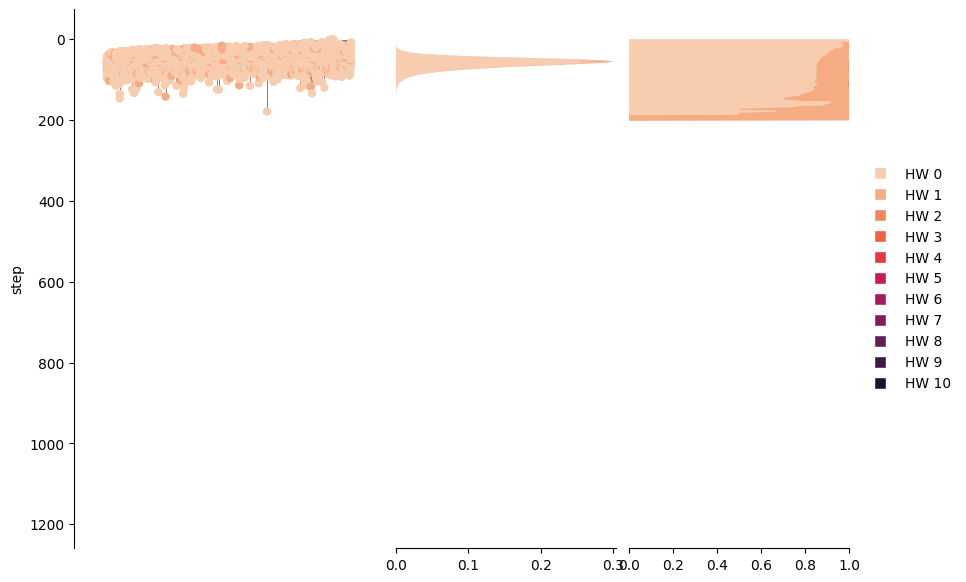

In [ ]:
# workaround: iplotx 1.7.x uses importlib.metadata without importing it
import importlib.metadata  # noqa: F401

import iplotx as ipx
import matplotlib.colors as mcolors
import matplotlib.pyplot as pyplot_phylo
from phyloframe import legacy as pfl

# Keep extinct lineages — uniform tip downsampling (and a unifurcation
# collapse) is enough to keep the rendered tree legible. Synthetic global
# root collapses multi-seed origins to a single root (iplotx requirement).
# Ladderize last so the rendering reflects the final topology.
MAX_TIPS = 10_000
pruned_df = (
    pfl.alifestd_downsample_tips_uniform_asexual(
        phylogeny_df,
        n_downsample=MAX_TIPS,
        seed=0,
    )
    .pipe(pfl.alifestd_add_global_root)
    .pipe(pfl.alifestd_collapse_unifurcations)
    .pipe(pfl.alifestd_try_add_ancestor_list_col)
    # Ladderize as the final structural step, then re-assign contiguous
    # ids so id == row index (iplotx requirement).
    .pipe(pfl.alifestd_ladderize_asexual)
    .pipe(pfl.alifestd_assign_contiguous_ids)
)

assert pfl.alifestd_validate(pruned_df)
print(f"phylogeny: {len(phylogeny_df)} total nodes")
print(f"downsampled tree: {len(pruned_df)} nodes")
print(f"leaf count: {pfl.alifestd_count_leaf_nodes(pruned_df)}")

fmt = f"0{PHYLO_N_SITES}b"
pruned_df = pruned_df.assign(
    strain=pruned_df["genome"].map(
        lambda g: None if np.isnan(g) else format(int(g), fmt)[::-1],
    ),
)

# With 2**N_SITES potential strains (1024 at N_SITES=10) per-strain colors
# become unworkable; instead key one sequential palette on Hamming weight,
# then map every strain (and every tip) to its corresponding HW color.
all_strains = sorted(
    (format(g, fmt)[::-1] for g in range(2**PHYLO_N_SITES)),
    key=lambda s: (s.count("1"), s),
)
hw_values = list(range(PHYLO_N_SITES + 1))
hw_palette = sns.color_palette("rocket_r", len(hw_values))
palette = {s: hw_palette[s.count("1")] for s in all_strains}

# iplotx accepts vertex_color as a positional list aligned to rows of the
# phyloframe shim; pass hex strings to keep matplotlib happy. The synthetic
# global root has no strain → render it as neutral gray.
vertex_colors = [
    "#cccccc" if strain is None else mcolors.to_hex(palette[strain])
    for strain in pruned_df["strain"]
]

# Per-strain prevalence series, in the same Hamming-weight order as the
# palette. Time is the y-axis (negated so it matches the iplotx vertical
# tree layout, where origin_time runs from 0 at the root downwards).
strain_cols = [
    f"Strain_{s}" for s in all_strains if f"Strain_{s}" in phylo_df.columns
]
stack_strains = [c[len("Strain_") :] for c in strain_cols]
steps = phylo_df["Step"].to_numpy()
y_steps = -steps
strain_layers = np.stack(
    [phylo_df[c].to_numpy() for c in strain_cols], axis=0
)
strain_colors = [palette[s] for s in stack_strains]

# Per-Hamming-weight aggregation, normalized so each row sums to 1
# (space-filling stackplot).
hw_layers = np.stack(
    [
        np.sum(
            [
                phylo_df[f"Strain_{s}"].to_numpy()
                for s in stack_strains
                if s.count("1") == w
            ]
            or [np.zeros_like(steps, dtype=float)],
            axis=0,
        )
        for w in hw_values
    ],
    axis=0,
)
hw_totals = hw_layers.sum(axis=0)
hw_layers_norm = np.where(hw_totals > 0, hw_layers / hw_totals, 0.0)

def _fill_horiz(ax, layers, colors):
    """Stackplot variant with time on the y-axis."""
    prev = np.zeros_like(layers[0])
    for layer, color in zip(layers, colors):
        cur = prev + layer
        ax.fill_betweenx(y_steps, prev, cur, color=color, edgecolor="none")
        prev = cur

from matplotlib.ticker import FuncFormatter

with tp.teed(
    pyplot_phylo.subplots,
    nrows=1,
    ncols=3,
    figsize=(10, 7),
    gridspec_kw={
        "width_ratios": [1.4, 1.0, 1.0],
        "wspace": 0.05,
    },
    sharey=True,
    teeplot_outattrs={
        "what": "phylogeny",
        "n_sites": PHYLO_N_SITES,
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (fig, axes):
    ax_tree, ax_strain, ax_hw = axes

    ipx.tree(
        pfl.alifestd_to_iplotx_pandas(pruned_df),
        ax=ax_tree,
        layout="vertical",
        vertex_color=vertex_colors,
        vertex_size=5,
        vertex_zorder=3,
        edge_color="gray",
        edge_linewidth=0.7,
        edge_zorder=1,
        margins=0.05,
        strip_axes=False,
    )

    _fill_horiz(ax_strain, strain_layers, strain_colors)
    ax_strain.set_xlim(0, strain_layers.sum(axis=0).max() * 1.02)

    _fill_horiz(ax_hw, hw_layers_norm, hw_palette)
    ax_hw.set_xlim(0, 1)

    # Time axis lives on the leftmost panel; show positive step numbers
    # even though the underlying coordinate is negated to align with the
    # iplotx layout.
    ax_tree.set_ylabel("step")
    ax_tree.yaxis.set_major_formatter(
        FuncFormatter(lambda v, _pos: f"{abs(int(round(-v)))}"),
    )
    ax_tree.tick_params(left=True, labelleft=True)
    for ax in (ax_strain, ax_hw):
        ax.tick_params(labelleft=False, left=False)

    sns.despine(ax=ax_tree, top=True, right=True, bottom=True)
    ax_tree.tick_params(bottom=False, labelbottom=False)
    sns.despine(ax=ax_strain, left=True)
    sns.despine(ax=ax_hw, left=True)

    # Hamming-weight legend (sequential palette: darker = more "1"
    # alleles). Per-strain entries would explode at 2**N_SITES; instead
    # all panels share the HW key.
    hw_handles = [
        pyplot_phylo.Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            markerfacecolor=hw_palette[i],
            markersize=8,
            label=f"HW {w}",
        )
        for i, w in enumerate(hw_values)
    ]
    ax_hw.legend(
        handles=hw_handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    fig.tight_layout()